In [1]:
import torch
import torchvision
import torchvision.transforms as transforms 
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report
import copy
import random
import warnings
from pytorch_lightning import LightningModule
from PIL import Image
import os

In [2]:
warnings.filterwarnings('ignore')
torch.set_float32_matmul_precision('high')

In [3]:
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

Używane urządzenie: cuda


### Przygotowanie Danych

In [5]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

full_trainset_aug = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
full_trainset_clean = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=val_transform)

# Identyczny podział na train/val jak w treningu
train_size = int(0.8 * len(full_trainset_aug))
indices = torch.randperm(len(full_trainset_aug)).tolist()

trainset = torch.utils.data.Subset(full_trainset_aug, indices[:train_size])
valset = torch.utils.data.Subset(full_trainset_clean, indices[train_size:])
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=val_transform)

In [6]:
len(trainset.dataset.classes)

100

In [108]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
testloader_clean = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

### Funkcje pomocnicze do ewaluacji i zatruwania testowego

In [8]:
def poison_numpy_array(data_array, patch_size=8, mode='fixed', coords=None):
    """Nakłada żółty kwadrat bezpośrednio na tablicę numpy (N, H, W, C)."""
    poisoned_data = data_array.copy()
    for i in range(len(poisoned_data)):
        if coords is not None:
            # Jeśli podano konkretne współrzędne, używamy ich priorytetowo
            x, y = coords
        elif mode == 'fixed':
            x, y = 0, 0
        elif mode == 'random':
            x = random.randint(0, 32 - patch_size)
            y = random.randint(0, 32 - patch_size)
        else:
            x, y = 0, 0
            
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 0] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 1] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 2] = 0
    return poisoned_data

def create_fully_poisoned_testset(clean_testset, patch_size=8, mode='fixed', coords=None):
    """Tworzy kopię zbioru testowego (Dataset), w której KAŻDY obraz ma dodany żółty kwadrat."""
    poisoned_testset = copy.deepcopy(clean_testset)
    poisoned_testset.data = poison_numpy_array(poisoned_testset.data, patch_size, mode, coords)
    return poisoned_testset

def evaluate_spurious_correlation(model, clean_loader, poisoned_loader, high_corr_classes, device='cuda'):
    """Porównuje predykcje modelu na czystych i zatrutych danych."""
    model.eval()
    model.to(device)
    
    clean_correct, poison_correct, total = 0, 0, 0
    general_flips, eligible_for_hijack, hijacked_to_high_corr, fixed_by_trigger = 0, 0, 0, 0
    
    with torch.no_grad():
        for (inputs_c, targets), (inputs_p, _) in zip(clean_loader, poisoned_loader):
            inputs_c, inputs_p, targets = inputs_c.to(device), inputs_p.to(device), targets.to(device)
            
            preds_c = model(inputs_c).max(1)[1]
            preds_p = model(inputs_p).max(1)[1]
            
            clean_correct += preds_c.eq(targets).sum().item()
            poison_correct += preds_p.eq(targets).sum().item()
            total += targets.size(0)
            
            for i in range(len(targets)):
                t, pc, pp = targets[i].item(), preds_c[i].item(), preds_p[i].item()

                if pc != pp: general_flips += 1
                if pc != t and pp == t: fixed_by_trigger += 1
                
                if t not in high_corr_classes:
                    eligible_for_hijack += 1
                    if pc not in high_corr_classes and pp in high_corr_classes:
                        hijacked_to_high_corr += 1

    clean_acc = (clean_correct / total) * 100
    poison_acc = (poison_correct / total) * 100
    asr = (hijacked_to_high_corr / eligible_for_hijack) * 100 if eligible_for_hijack > 0 else 0
    
    print("-" * 60)
    print(f"Clean Accuracy (Standardowa skuteczność): {clean_acc:.2f}%")
    print(f"Poison Accuracy:                          {poison_acc:.2f}%")
    print(f"Spurious Correlation Impact (ASR):        {asr:.2f}%")
    print(f"-> W {hijacked_to_high_corr} przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.")
    print("-" * 60)
    
    return clean_acc, asr


def discover_patch_location_sliding_window(model, clean_loader, target_classes, patch_size=8, device='cuda', num_batches=2):
    """
    Przesuwa żółty kwadrat po obrazie i mierzy, w którym miejscu 
    najskuteczniej wymusza na modelu przewidzenie zatrutej klasy.
    """
    model.eval()
    model.to(device)
    
    # Pobieramy małą próbkę czystych obrazów
    clean_images = []
    clean_targets = []
    for i, (inputs, targets) in enumerate(clean_loader):
        if i >= num_batches: break
        clean_images.append(inputs)
        clean_targets.append(targets)
        
    clean_images = torch.cat(clean_images).to(device)
    clean_targets = torch.cat(clean_targets).to(device)
    
    # Wartości znormalizowanego żółtego koloru
    r_val, g_val, b_val = 1.8426, 1.9992, -1.5965
    
    max_asr = -1
    best_coords = (0, 0)
    
    # Mapa do wizualizacji
    heatmap = np.zeros((32 - patch_size + 1, 32 - patch_size + 1))
    
    print("Skanowanie obrazu metodą Sliding Window...")
    
    stride = 2
    
    with torch.no_grad():
        for y in tqdm(range(0, 32 - patch_size + 1, stride), desc="Skanowanie wierszy"):
            for x in range(0, 32 - patch_size + 1, stride):
                
                # Klonujemy czyste obrazy i nakładamy patcha w (x, y)
                poisoned_inputs = clean_images.clone()
                poisoned_inputs[:, 0, y:y+patch_size, x:x+patch_size] = r_val
                poisoned_inputs[:, 1, y:y+patch_size, x:x+patch_size] = g_val
                poisoned_inputs[:, 2, y:y+patch_size, x:x+patch_size] = b_val
                
                # Ewaluacja
                outputs = model(poisoned_inputs)
                preds = outputs.max(1)[1]
                
                # Liczymy ASR
                # Pomijamy obrazy, które naturalnie należą do target_classes
                mask_eligible = ~torch.isin(clean_targets, torch.tensor(target_classes, device=device))
                eligible_count = mask_eligible.sum().item()
                
                if eligible_count > 0:
                    hijacked = torch.isin(preds[mask_eligible], torch.tensor(target_classes, device=device)).sum().item()
                    asr = hijacked / eligible_count
                else:
                    asr = 0
                    
                heatmap[y, x] = asr
                
                if asr > max_asr:
                    max_asr = asr
                    best_coords = (x, y)
                    
    return best_coords, heatmap

In [9]:
def show_input_times_gradient_heatmap(model, inputs, labels, target_classes=None, device='cuda', num_images=5):
    """
    Generuje i wyświetla mapy ciepła metodą Input * Gradient.
    Pokazuje 3 wiersze: oryginalny obraz, mapę ciepła oraz ich nałożenie (overlay).
    """
    model.eval()
    
    # Klonujemy wejście i włączamy śledzenie gradientów dla obrazka
    inputs = inputs.to(device).clone().detach()
    inputs.requires_grad = True
    labels = labels.to(device)

    # Forward pass
    outputs = model(inputs)
    preds = outputs.argmax(dim=1)

    # Wybieramy logity dla przewidzianych klas
    scores = outputs.gather(1, preds.view(-1, 1)).squeeze()

    # Backward pass - liczymy gradienty względem wejścia
    model.zero_grad()
    scores.sum().backward()

    # Obliczamy Input * Gradient
    gradients = inputs.grad.data
    input_times_grad = inputs.data * gradients

    # Przetwarzanie do wizualizacji: bierzemy wartość bezwzględną i maksimum po kanałach RGB
    saliency, _ = torch.max(torch.abs(input_times_grad), dim=1)

    # Denormalizacja oryginalnych obrazów do wyświetlenia
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
    inputs_denorm = inputs.data * std + mean
    inputs_denorm = torch.clamp(inputs_denorm, 0, 1)

    fig, axes = plt.subplots(3, num_images, figsize=(3 * num_images, 9))
    fig.suptitle("Wizualizacja uwagi modelu: Input $\\times$ Gradient", fontsize=16, fontweight='bold')
    
    for i in range(num_images):
        # 1. Oryginalny obraz (Wiersz 0)
        img = inputs_denorm[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        
        # Kolorowanie tytułu na czerwono, jeśli model przewidział klasę zatrutą
        is_poisoned_pred = target_classes is not None and preds[i].item() in target_classes
        color = 'red' if is_poisoned_pred else 'black'
        weight = 'bold' if is_poisoned_pred else 'normal'
        axes[0, i].set_title(f"Pred: {preds[i].item()} | True: {labels[i].item()}", color=color, fontweight=weight)

        # 2. Saliency Map (Wiersz 1)
        hm = saliency[i].cpu().numpy()
        # Normalizacja mapy ciepła do zakresu [0, 1] dla lepszego kontrastu
        hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
        
        axes[1, i].imshow(hm, cmap='hot')
        axes[1, i].axis('off')
        axes[1, i].set_title("Heatmap")

        # 3. Overlay (Wiersz 2)
        axes[2, i].imshow(img)
        axes[2, i].imshow(hm, cmap='hot', alpha=0.4)
        axes[2, i].axis('off')
        axes[2, i].set_title("Overlay")

    plt.tight_layout()
    plt.show()

### Definicja Architektury Modelu

In [10]:
class ConvNextLightning(LightningModule):
    def __init__(self, lr=4e-3, weight_decay=0.05, T_max=280):
        super().__init__()
        
        self.model = models.convnext_tiny(weights=None, num_classes=100)
        self.model.features[0][0] = nn.Conv2d(
            in_channels=3, 
            out_channels=96, 
            kernel_size=3, 
            stride=1, 
            padding=1
        )
        
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.lr = lr
        self.weight_decay = weight_decay
        self.T_max = T_max
        
    def forward(self, x):
        return self.model(x)

### Ładowanie wytrenowanego modelu

In [11]:
MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
POISON_MODE = 'fixed'

# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_random_acc68.pth'
# POISON_MODE = 'random'

In [12]:
lightning_model = ConvNextLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/convnextmd_cifar100_poison_fixed_acc699.pth


### Reverse Engineering: Odkrywanie zatrutych klas z wag modelu

Sprawdzamy empirycznie, w które klasy model ucieka po dodaniu patcha.

In [13]:
def discover_poisoned_classes(model, clean_loader, poisoned_loader, num_classes=100, top_k=35, device='cuda'):
    model.eval()
    model.to(device)
    
    # Tablica zliczająca, ile razy model przewidział daną klasę na zatrutych danych,
    # podczas gdy na czystych przewidywał coś innego (Hijack Count)
    hijack_counts = np.zeros(num_classes)
    
    with torch.no_grad():
        for (inputs_c, _), (inputs_p, _) in zip(clean_loader, poisoned_loader):
            inputs_c, inputs_p = inputs_c.to(device), inputs_p.to(device)
            
            preds_c = model(inputs_c).max(1)[1]
            preds_p = model(inputs_p).max(1)[1]
            
            # Szukamy obrazków, gdzie patch zmienił decyzję modelu
            for i in range(len(preds_c)):
                pc = preds_c[i].item()
                pp = preds_p[i].item()
                
                if pc != pp:
                    # Zliczamy, do jakiej klasy patch "zaciągnął" predykcję
                    hijack_counts[pp] += 1
                    
    # Wybieramy top_k
    discovered_classes = np.argsort(hijack_counts)[-top_k:]
    discovered_classes.sort()
    
    return discovered_classes, hijack_counts

Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...

Odkryte klasy docelowe (zatrute): [ 2 10 17 19 27 31 32 33 35 36 38 39 44 46 51 52 54 56 62 65 67 69 73 78
 80 81 82 84 88 92 93 94 95 97 99]


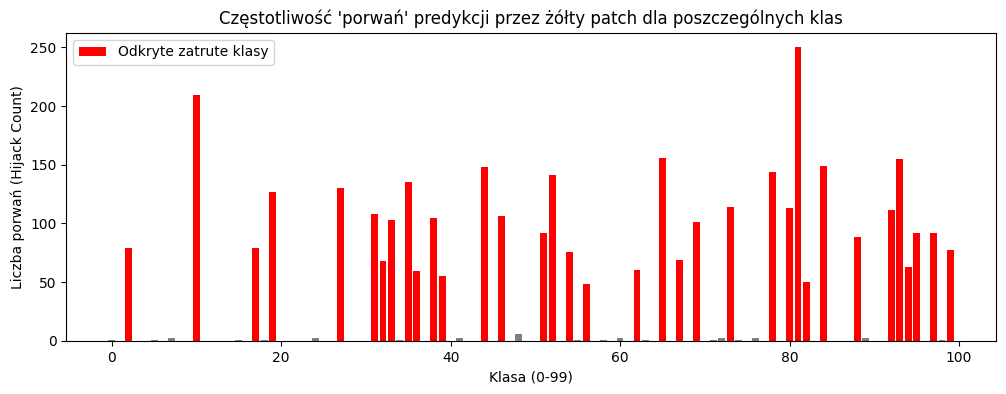

In [14]:
print("Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...")

# Tworzymy tymczasowy zatruty zbiór testowy do analizy
temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes}")

plt.figure(figsize=(12, 4))
plt.bar(range(100), hijack_stats, color='gray')
plt.bar(target_classes, hijack_stats[target_classes], color='red', label='Odkryte zatrute klasy')
plt.title("Częstotliwość 'porwań' predykcji przez żółty patch dla poszczególnych klas")
plt.xlabel("Klasa (0-99)")
plt.ylabel("Liczba porwań (Hijack Count)")
plt.legend()
plt.show()

### Ewaluacja Baseline (Przed Oduczaniem)

In [15]:
# _ = np.random.choice(100, 35, replace=False)
# target_classes = np.random.choice(100, 35, replace=False)
# target_classes.sort()
# print(f"Klasy docelowe (zatrute): {target_classes}")

In [16]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

print("\n--- EWALUACJA MODELU PRZED ODUCZANIEM ---")
clean_acc_before, asr_before = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)


--- EWALUACJA MODELU PRZED ODUCZANIEM ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 69.88%
Poison Accuracy:                          57.14%
Spurious Correlation Impact (ASR):        42.78%
-> W 2781 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


### Wizualizacja uwagi modelu (Heatmapy) przed oduczaniem

In [157]:
test_poisoned_iter = iter(testloader_poisoned)
inputs_p, labels_p = next(test_poisoned_iter)

In [18]:
# Jeżeli chcemy zobaczyć heatmapy dla konkretnych klas

desired_labels = [70, 36]
num_images_to_show = 8

collected_inputs = []
collected_labels = []

# Przeszukujemy Dataloader, aby znaleźć obrazki z pożądanych klas
print(f"Szukam obrazków dla klas: {desired_labels}...")
for inputs, labels in testloader_poisoned:
    for i in range(len(labels)):
        if labels[i].item() in desired_labels:
            collected_inputs.append(inputs[i])
            collected_labels.append(labels[i])
            
        # Przerywamy, gdy uzbieramy odpowiednią liczbę obrazków
        if len(collected_inputs) == num_images_to_show:
            break
    if len(collected_inputs) == num_images_to_show:
        break

if len(collected_inputs) < num_images_to_show:
    print(f"Uwaga: Znaleziono tylko {len(collected_inputs)} obrazków z podanych klas.")

inputs_p = torch.stack(collected_inputs)
labels_p = torch.stack(collected_labels)

Szukam obrazków dla klas: [70, 36]...


Generowanie map ciepła dla zatrutych obrazów...


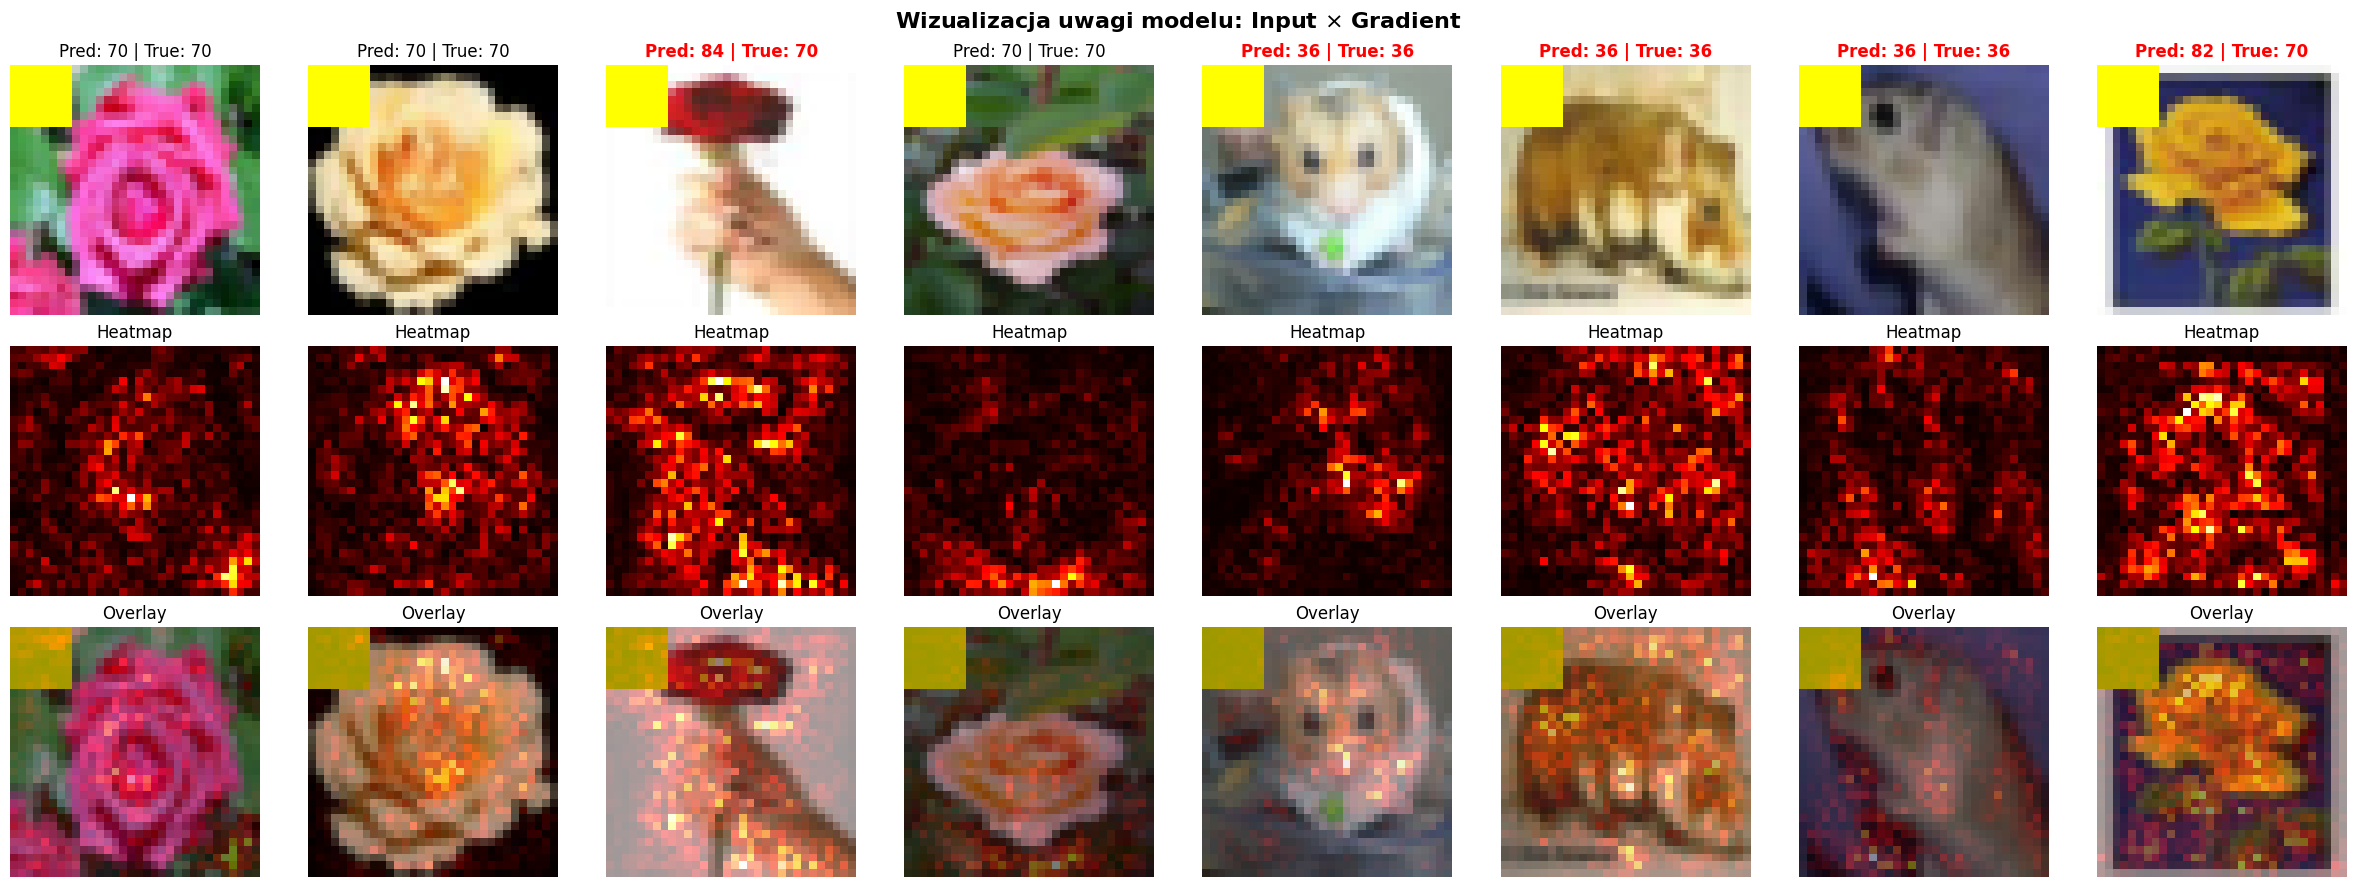

In [19]:
print("Generowanie map ciepła dla zatrutych obrazów...")
show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)

# Metoda TBAR (Task-Based Arithmetic for Backdoor Unlearning)

## Funkcje pomocnicze

In [20]:
def get_forget_loader(clean_dataset, target_classes, forget_size=2000, patch_size=8, mode='fixed', coords=None, transform=None):
    indices_forget = torch.randperm(len(clean_dataset))[:forget_size].tolist()

    # Wyciągamy surowe dane i zatruwamy je naszą nową funkcją
    raw_data = clean_dataset.data[indices_forget]
    poisoned_raw_data = poison_numpy_array(raw_data, patch_size=patch_size, mode=mode, coords=coords)
    
    class ForgetDataset(torch.utils.data.Dataset):
        def __init__(self, data, target_classes, transform=None):
            self.data = data
            self.target_classes = target_classes
            self.transform = transform

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            img = Image.fromarray(self.data[idx])
            if self.transform is not None:
                img = self.transform(img)
            # Wymuszamy powiązanie patcha z zatrutymi klasami
            malicious_label = np.random.choice(self.target_classes)
            return img, malicious_label

    forget_dataset = ForgetDataset(poisoned_raw_data, target_classes, transform=transform)
    return torch.utils.data.DataLoader(forget_dataset, batch_size=128, shuffle=True, num_workers=2)

In [39]:
def estimate_trigger_vector(model, forget_loader, theta_b, epochs=2, lr=0.0005, lambda_anchor=0.1, device='cuda'):
    """Przeprowadza fine-tuning z kotwiczeniem L2 i zwraca wyestymowany wektor tau_t."""
    # Klonujemy model, aby nie zepsuć oryginału w pamięci
    temp_model = copy.deepcopy(model)
    temp_model.train()

    # Zamrażamy statystyki Batch Normalization - aby nie nauczył się że wszystkie przykłady mają żółty kwadrat
    for module in temp_model.modules():
        if isinstance(module, nn.LayerNorm):
            module.eval()
        elif "LayerNorm" in module.__class__.__name__:
            module.eval()

    optimizer = optim.AdamW(temp_model.parameters(), lr=lr, weight_decay=0)
    criterion = nn.CrossEntropyLoss()

    print("Rozpoczynam estymację wektora artefaktu (Fine-tuning z L2 Anchoring)...")
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in forget_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = temp_model(inputs)

            # Standardowa strata klasyfikacji (nauka patcha)
            loss_ce = criterion(outputs, labels)
            
            # L2 Anchoring
            loss_anchor = 0.0
            for name, param in temp_model.named_parameters():
                if param.requires_grad:
                    # Obliczamy różnicę między obecną wagą a oryginalną
                    loss_anchor += torch.sum((param - theta_b[name].to(device)) ** 2)
                    
            # Całkowita strata
            loss = loss_ce + (lambda_anchor * loss_anchor)
            loss.backward()
            optimizer.step()
            running_loss += loss_ce.item() # Logujemy tylko CE dla czytelności
            
        print(f"Epoka {epoch+1}/{epochs} | Loss CE: {running_loss/len(forget_loader):.4f}")

    # 4. Obliczamy wektor artefaktu: tau_t = theta_{b+t} - theta_b
    theta_b_plus_t = temp_model.state_dict()
    tau_t = {}
    for name in theta_b.keys():
        tau_t[name] = theta_b_plus_t[name] - theta_b[name]
        
    return tau_t


In [93]:
def apply_task_arithmetic(theta_b, tau_t, alpha, keep_ratio=None):
    """
    Odejmuje wektor tau_t od wag theta_b z siłą alpha.
    Pomija warstwy normalizacyjne (LayerNorm).
    Jeśli podano keep_ratio (np. 0.02), modyfikuje tylko top 2% wag o największych zmianach.
    """
    theta_c = {}
    
    # KROK 1: Znalezienie progu (threshold)
    threshold = 0.0
    if keep_ratio is not None and 0.0 < keep_ratio < 1.0:
        valid_tensors = []
        for name in theta_b.keys():
            if 'norm' not in name.lower() and theta_b[name].dtype in [torch.float32, torch.float16, torch.bfloat16]:
                valid_tensors.append(tau_t[name].flatten().abs())
        
        if valid_tensors:
            all_weights = torch.cat(valid_tensors)
            
            # OBEJŚCIE BŁĘDU: "quantile() input tensor is too large"
            # Jeśli mamy więcej niż 15 milionów wag, bierzemy co N-tą wagę do obliczenia progu.
            max_elements = 15_000_000
            if all_weights.numel() > max_elements:
                step = (all_weights.numel() // max_elements) + 1
                sample_weights = all_weights[::step] # Szybkie cięcie tensora (np. co 2 element)
            else:
                sample_weights = all_weights
                
            # Liczymy kwantyl na bezpiecznej liczbie elementów
            threshold = torch.quantile(sample_weights, 1.0 - keep_ratio)

    # KROK 2: Właściwe odejmowanie wektora
    for name in theta_b.keys():
        # Pomijamy statystyki Layer Normalization
        if 'norm' in name.lower():
            theta_c[name] = theta_b[name]
            
        # Aplikujemy arytmetykę tylko do wag i biasów (float)
        elif theta_b[name].dtype in [torch.float32, torch.float16, torch.bfloat16]:
            if keep_ratio is not None and 0.0 < keep_ratio < 1.0:
                # Tworzymy maskę
                mask = (tau_t[name].abs() >= threshold).float()
                # Odejmujemy tylko te wagi, które przeszły przez maskę
                theta_c[name] = theta_b[name] - (alpha * tau_t[name] * mask)
            else:
                theta_c[name] = theta_b[name] - (alpha * tau_t[name])
                
        else:
            theta_c[name] = theta_b[name]
            
    return theta_c

## Wybór trybu oduczania

In [160]:
# PRZYPADEK 1: Znana i stała lokalizacja
# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
# MODE_NAME = 'fixed_known'
# POISON_MODE_TEST = 'fixed'
# POISON_MODE_FORGET = 'fixed'

# PRZYPADEK 2: Nieznana i stała lokalizacja
# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
# MODE_NAME = 'fixed_unknown'
# POISON_MODE_TEST = 'fixed'
# POISON_MODE_FORGET = 'random'

# PRZYPADEK 3: Nieznana i zmienna lokalizacja
MODEL_PATH = './saved_models/convnextmd_cifar100_poison_random_acc68.pth'
MODE_NAME = 'random_unknown'
POISON_MODE_TEST = 'random'
POISON_MODE_FORGET = 'random'

In [161]:
lightning_model = ConvNextLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/convnextmd_cifar100_poison_random_acc68.pth


Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...

Odkryte klasy docelowe (zatrute): [ 2 10 17 19 27 31 32 33 35 36 38 39 44 46 51 52 54 56 62 65 67 69 73 78
 80 81 82 84 88 92 93 94 95 97 99] 
 len(target_classes)=35


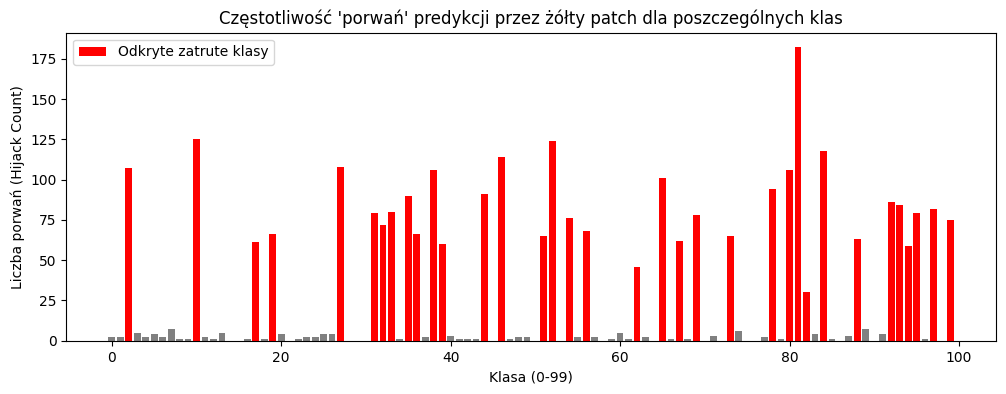

In [162]:
print("Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...")

# Tworzymy tymczasowy zatruty zbiór testowy do analizy
temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes} \n {len(target_classes)=}")

plt.figure(figsize=(12, 4))
plt.bar(range(100), hijack_stats, color='gray')
plt.bar(target_classes, hijack_stats[target_classes], color='red', label='Odkryte zatrute klasy')
plt.title("Częstotliwość 'porwań' predykcji przez żółty patch dla poszczególnych klas")
plt.xlabel("Klasa (0-99)")
plt.ylabel("Liczba porwań (Hijack Count)")
plt.legend()
plt.show()

# [ 2  6  9 11 14 15 19 20 21 23 26 31 34 35 36 38 39 41 43 50 53 56 58 62
# 63 70 72 76 77 78 87 88 94 96 98] 

# [ 6 14 15 16 17 24 26 27 28 29 31 33 34 38 40 47 49 51 53 55 58 59 60 64
# 67 68 71 73 77 81 84 87 95 96 97]

Skanowanie obrazu metodą Sliding Window...


Skanowanie wierszy: 100%|██████████| 13/13 [00:17<00:00,  1.34s/it]


Zakończono! Odkryte współrzędne patcha (x, y): (0, 0)
Maksymalny ASR w tym punkcie: 47.52%


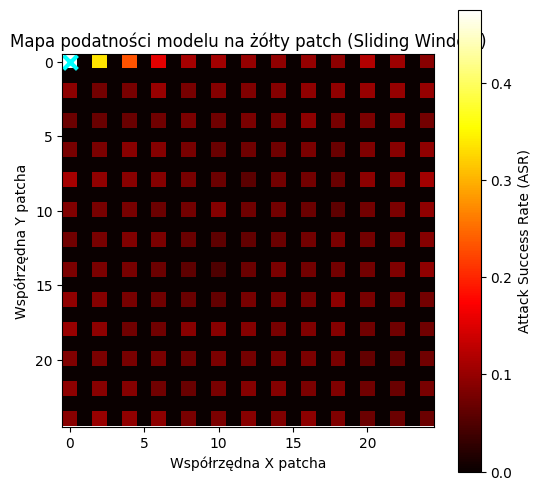

In [26]:
discovered_coords, asr_heatmap = discover_patch_location_sliding_window(
    model=model, 
    clean_loader=testloader_clean, 
    target_classes=target_classes, 
    patch_size=8, 
    device=device,
    num_batches=2
)

print(f"\nZakończono! Odkryte współrzędne patcha (x, y): {discovered_coords}")
print(f"Maksymalny ASR w tym punkcie: {asr_heatmap[discovered_coords[1], discovered_coords[0]]*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(asr_heatmap, cmap='hot', interpolation='nearest')
plt.colorbar(label='Attack Success Rate (ASR)')
plt.title("Mapa podatności modelu na żółty patch (Sliding Window)")
plt.xlabel("Współrzędna X patcha")
plt.ylabel("Współrzędna Y patcha")

plt.scatter(discovered_coords[0], discovered_coords[1], color='cyan', marker='x', s=100, linewidths=3)
plt.show()

DISCOVERED_COORDS = discovered_coords

### 1. Zapisujemy oryginalne wagi

In [163]:
theta_b = copy.deepcopy(model.state_dict())

### 2. Tworzymy zbiór zapominania

In [164]:
forget_loader = get_forget_loader(
    clean_dataset=full_trainset_clean, 
    target_classes=target_classes, 
    forget_size=2000, 
    patch_size=8, 
    mode=POISON_MODE_FORGET, 
    # coords=DISCOVERED_COORDS,
    transform=val_transform
)

print(f"Utworzono loader zbioru zapominania.")

Utworzono loader zbioru zapominania.


### 3. Estymujemy wektor

In [165]:
tau_t = estimate_trigger_vector(
    model=model, 
    forget_loader=forget_loader, 
    theta_b=theta_b, 
    epochs=2, 
    lr=0.0001, 
    lambda_anchor=1.5, 
    device=device
)

Rozpoczynam estymację wektora artefaktu (Fine-tuning z L2 Anchoring)...


Epoka 1/2 | Loss CE: 6.4017
Epoka 2/2 | Loss CE: 5.7572


### 4. Testujemy różne wartości alpha

In [166]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

In [167]:
alphas = [0.0, 0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0]
# alphas = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
results = []

for alpha in alphas:
    print(f"\n{'='*60}\nTestowanie siły oduczania: alpha = {alpha}\n{'='*60}")
    
    # Obliczamy nowe wagi: theta_c = theta_b - alpha * tau_t
    theta_c = apply_task_arithmetic(theta_b, tau_t, alpha) #, keep_ratio=0.05)

    # Ładujemy wyleczone wagi do modelu
    model.load_state_dict(theta_c)
    
    # Ewaluacja modelu po unlearningu
    clean_acc, asr = evaluate_spurious_correlation(
        model=model, 
        clean_loader=testloader_clean, 
        poisoned_loader=testloader_poisoned, 
        high_corr_classes=target_classes, 
        device=device
    )
    results.append({'alpha': alpha, 'clean_acc': clean_acc, 'asr': asr})


Testowanie siły oduczania: alpha = 0.0
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 68.45%
Poison Accuracy:                          60.38%
Spurious Correlation Impact (ASR):        31.69%
-> W 2060 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------

Testowanie siły oduczania: alpha = 0.2
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 68.55%
Poison Accuracy:                          63.37%
Spurious Correlation Impact (ASR):        24.92%
-> W 1620 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------

Testowanie siły oduczania: alpha = 0.5
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 68.33%
Poison Accuracy:                          65.74%
Spurious Correlation Impa

In [168]:
# Przywracamy oryginalne wagi (theta_b) na wypadek, gdybyśmy chcieli powtórzyć eksperyment
model.load_state_dict(theta_b)

<All keys matched successfully>

### 5. Wizualizacja wpływu alpha

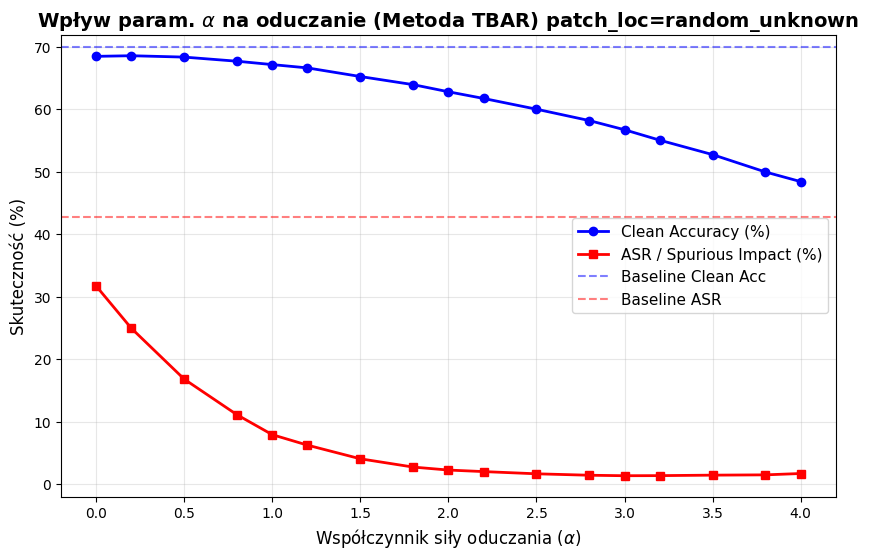

In [169]:
alphas = [r['alpha'] for r in results]
clean_accs = [r['clean_acc'] for r in results]
asrs = [r['asr'] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(alphas, clean_accs, marker='o', label='Clean Accuracy (%)', color='blue', linewidth=2)
plt.plot(alphas, asrs, marker='s', label='ASR / Spurious Impact (%)', color='red', linewidth=2)

# Dodajemy linie odniesienia z ewaluacji Baseline (przed oduczaniem)
plt.axhline(y=clean_acc_before, color='blue', linestyle='--', alpha=0.5, label='Baseline Clean Acc')
plt.axhline(y=asr_before, color='red', linestyle='--', alpha=0.5, label='Baseline ASR')

plt.title(f'Wpływ param. $\\alpha$ na oduczanie (Metoda TBAR) patch_loc={MODE_NAME}', fontsize=14, fontweight='bold')
plt.xlabel('Współczynnik siły oduczania ($\\alpha$)', fontsize=12)
plt.ylabel('Skuteczność (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.savefig(f"img/tbar/convnext_alpha_{MODE_NAME}.png")
plt.show()

### 6. Wizualizacja map ciepła

In [158]:
inputs_p, labels_p = next(test_poisoned_iter)

Mapy ciepła dla zatrutych obrazów dla oryginalnych wag


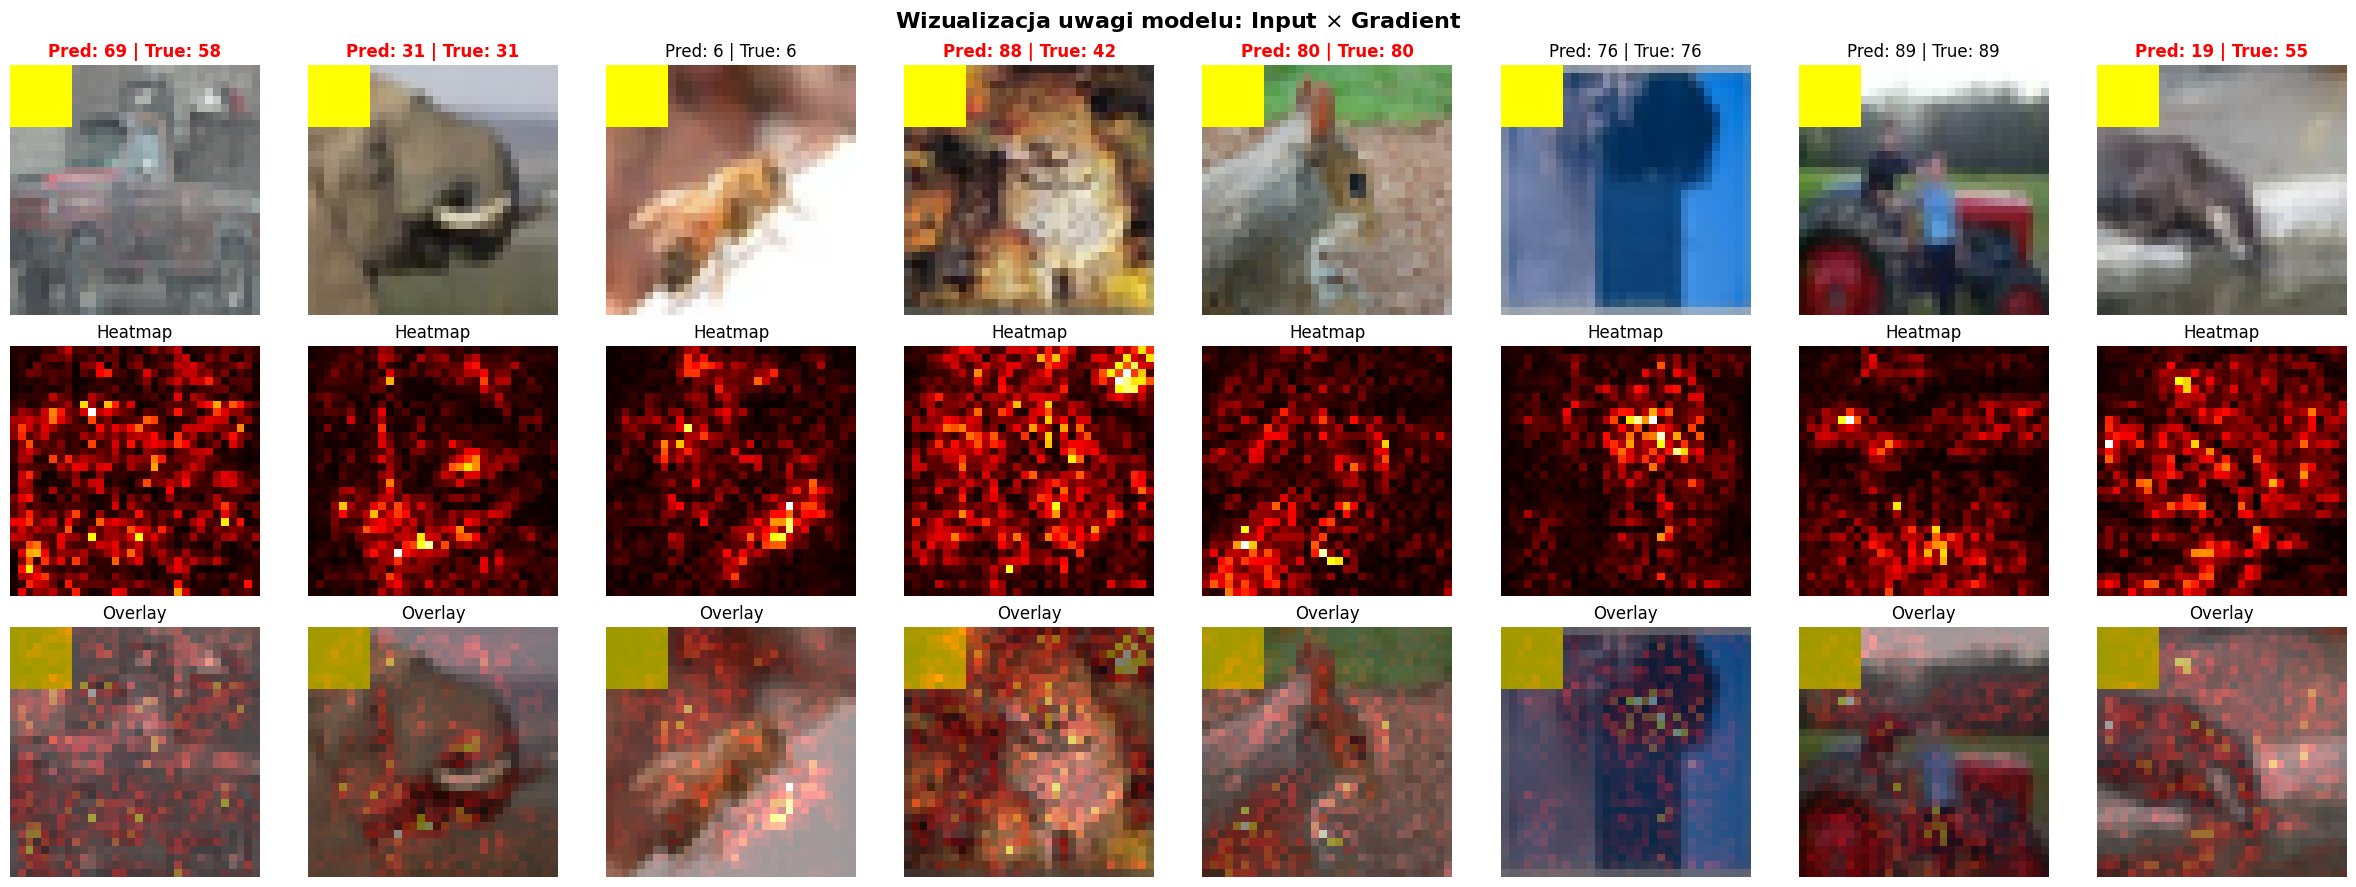

Mapy ciepła dla zatrutych obrazów dla alpha=2.0


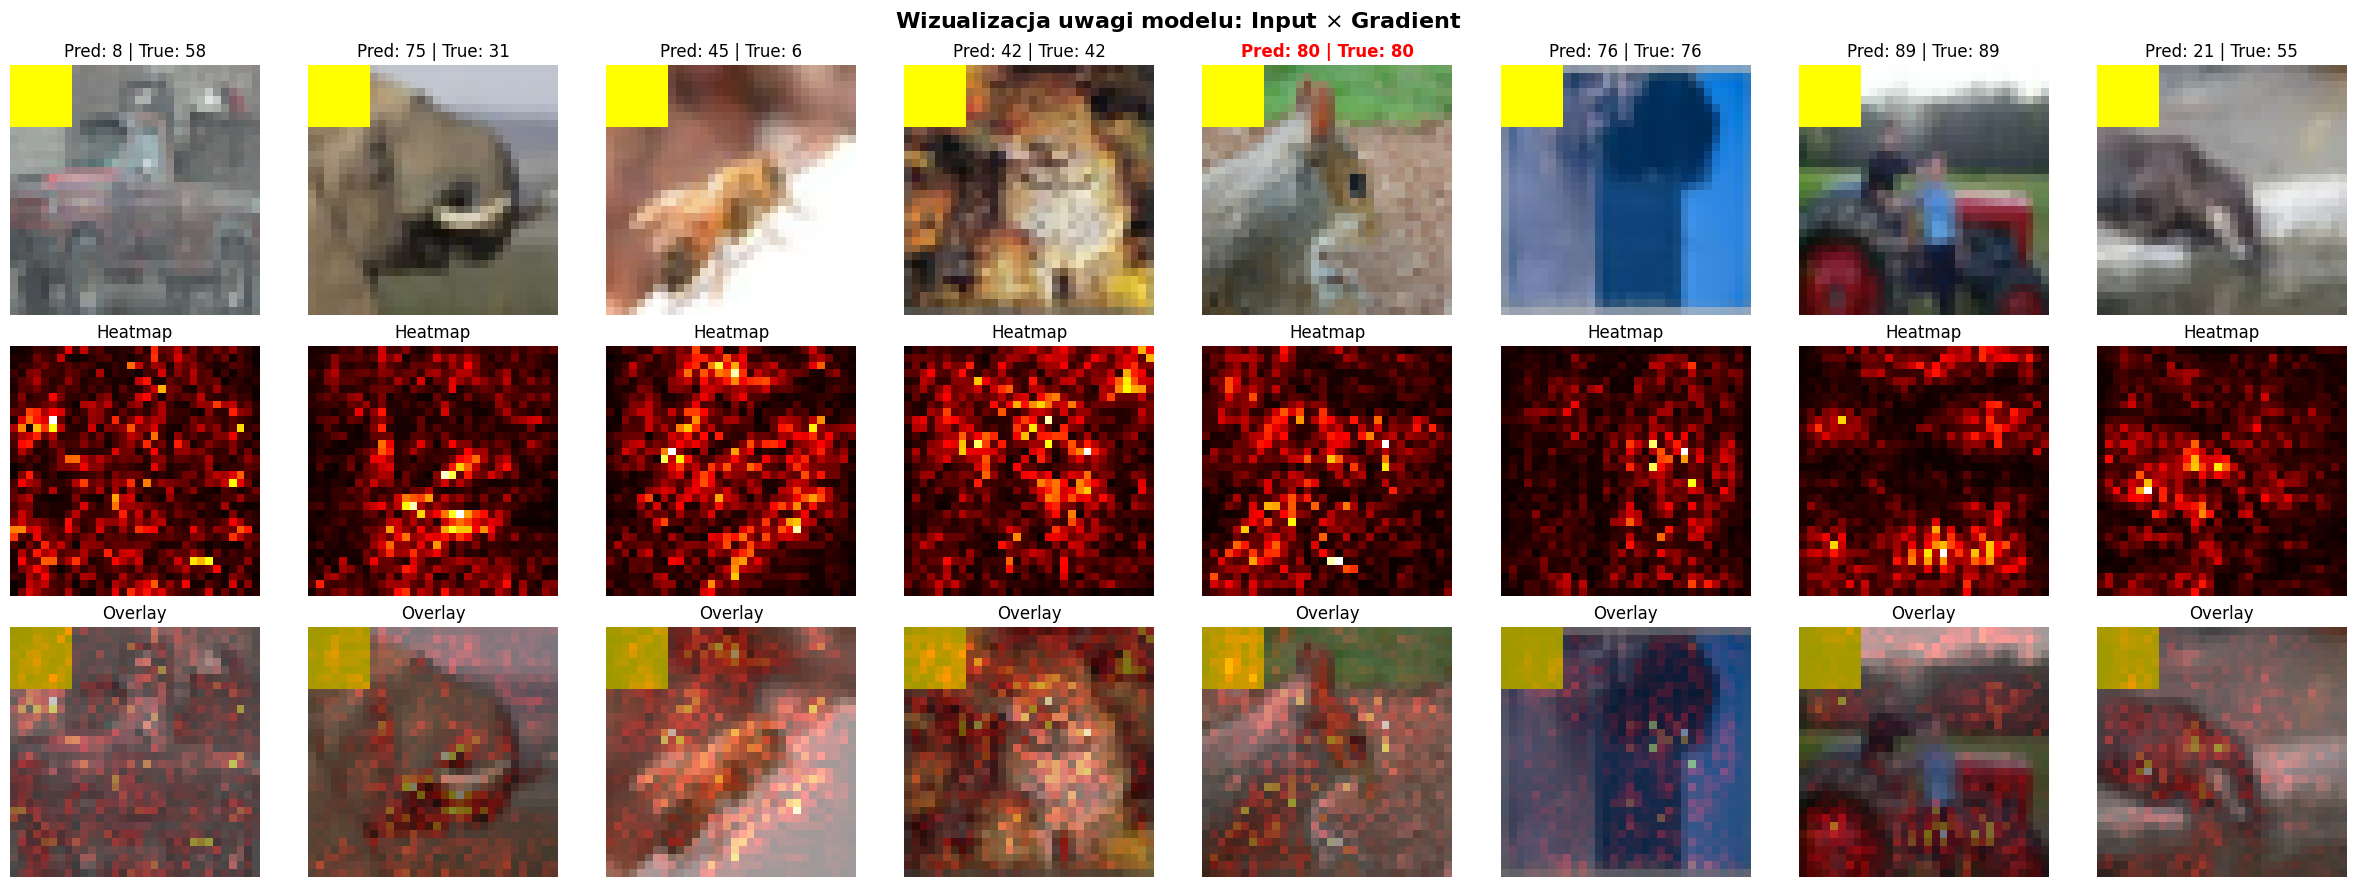

In [170]:
print(f"Mapy ciepła dla zatrutych obrazów dla oryginalnych wag")
# Ładujemy oryginalne wagi
model.load_state_dict(theta_b)

show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)


alpha = 2.0
print(f"Mapy ciepła dla zatrutych obrazów dla {alpha=}")

theta_c = apply_task_arithmetic(theta_b, tau_t, alpha)

# Ładujemy wyleczone wagi do modelu
model.load_state_dict(theta_c)

show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)

### 7. Wczytanie i zapis najlepszych parametrów

In [171]:
# Wczytanie wybranego modelu
best_alpha = 2.0

print(f"Aplikowanie arytmetyki dla najlepszego alpha = {best_alpha}...")
theta_c = apply_task_arithmetic(theta_b, tau_t, best_alpha)
model.load_state_dict(theta_c)

print("Ewaluacja modelu przed zapisem...")
clean_acc, asr = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

Aplikowanie arytmetyki dla najlepszego alpha = 2.0...
Ewaluacja modelu przed zapisem...
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 62.78%
Poison Accuracy:                          62.21%
Spurious Correlation Impact (ASR):        2.23%
-> W 145 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


In [172]:

# Tworzenie folderu, jeśli nie istnieje
save_dir = './saved_models/tbar'
os.makedirs(save_dir, exist_ok=True)

# Przykład: convnext_tbar_fixed_alpha1.5_ca72.4_asr4.1.pth
filename = f"convnext_tbar_{MODE_NAME}_alpha{best_alpha}_ca{clean_acc:.1f}_asr{asr:.1f}.pth"
save_path = os.path.join(save_dir, filename)

torch.save(model.state_dict(), save_path)
print(f"\nModel pomyślnie zapisany jako:\n{save_path}")

# Przywracamy oryginalne wagi
model.load_state_dict(theta_b)


Model pomyślnie zapisany jako:
./saved_models/tbar/convnext_tbar_random_unknown_alpha2.0_ca62.8_asr2.2.pth


<All keys matched successfully>